In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import math
import datamol as dm
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

# Functions

In [2]:


def plot_random_growth_curve(df, compound_col="Compound", smiles_col="Smiles"):
    """
    Randomly select a compound and plot its growth curve (OD vs time).
    
    Args:
        df (pd.DataFrame): DataFrame containing compound info and t_* columns.
        compound_col (str): Column name for compound identifier.
        smiles_col (str): Optional column for SMILES strings (if present).
    """
    # Identify timepoint columns (those starting with "t_")
    time_cols = [col for col in df.columns if col.startswith("t_")]
    
    # Randomly select one compound
    row = df.sample(1).iloc[0]
    compound_name = row[compound_col]
    smiles = row.get(smiles_col, None)
    
    # Extract time (float from column names like 't_0.167')
    times = [float(col.replace("t_", "")) for col in time_cols]
    od_values = row[time_cols].values.astype(float)
    
    # Plot
    plt.figure(figsize=(8,5))
    plt.plot(times, od_values, marker='o', linewidth=2, color='steelblue')
    plt.xlabel("Time (hours)", fontsize=12)
    plt.ylabel("OD (Optical Density)", fontsize=12)
    plt.title(f"Growth Curve — {compound_name}", fontsize=14)
    
    # Add SMILES to title if available
    if smiles:
        plt.suptitle(f"SMILES: {smiles}", fontsize=9, y=0.92, color="gray")
    
    plt.grid(alpha=0.3)
    plt.show()
    
    return compound_name


def compute_scaffold(smiles):
    if not isinstance(smiles, str):  # Guard against NaN or non-string
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
    return None

def maccs_to_fp(smile):
    try:

        return dm.to_fp(smile, fp_type="maccs")
    except Exception as e:

        print(f"Error processing SMILES '{smile}': {e}")
        return np.nan


def ecfp_to_fp(smile):
    try:

        return dm.to_fp(smile, fp_type="ecfp")
    except Exception as e:

        print(f"Error processing SMILES '{smile}': {e}")
        return np.nan


def rdkit_to_fp(smile):
    try:

        return dm.to_fp(smile, fp_type="rdkit")
    except Exception as e:

        print(f"Error processing SMILES '{smile}': {e}")
        return np.nan

def plot_hist_od_distributions_long(
    title,
    correct_uncorrect,
    dataset,
    df_long,
    bins,                       
    concentration,
    max_density,
    max_x,
    plot_pos_ctrls: bool = True, 
    save_path: bool = False,
):
    """
    Plot overlaid OD histograms by Control_Label at each timepoint,
    allowing a different `bins` specification for each label.
    """
    # ── helper to fetch per-label bins ───────────────────────────────────────────
    def _bins_for(label):
        if not isinstance(bins, dict):
            return bins
        return bins.get(label, 30)

    base_labels = [-1, 0, 1]
    labels      = base_labels if plot_pos_ctrls else [-1, 0]
    colors      = {-1: '#1f77b4', 0: '#ff7f0e', 1: '#2ca02c'}
    label_names = {-1: "Negative Control", 0: "Test Compound", 1: "Positive Control"}

    # 1) Extract only rows at the requested concentration
    df_sub = df_long[df_long['Concentration'] == concentration]

    # 2) Compute the ordered list of numerically‐sorted timepoints
    #    (so we use the same order for plotting and for knowing how many axes to keep)
    timepoints = np.sort(df_sub['Timepoint'].unique())

    # 3) Create a 2×4 grid (eight possible axes)
    #fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    #axes = axes.flatten()

    n_timepoints = len(timepoints)
    ncols = 4
    nrows = math.ceil(n_timepoints / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5*nrows))
    axes = axes.flatten()

    for i, tp in enumerate(timepoints):
        ax     = axes[i]
        sub_tp = df_sub[df_sub['Timepoint'] == tp]

        # Plot one histogram per Control_Label
        for lab in labels:
            grp = sub_tp[sub_tp['Control_Label'] == lab]
            ax.hist(
                grp['OD'],
                bins=_bins_for(lab),
                alpha=0.30,
                density=True,
                label=label_names[lab],
                color=colors[lab],
                histtype='stepfilled',
                edgecolor='black',
                linewidth=0.7
            )

        # Compute median and MAD on test compounds (Control_Label == 0)
        test_grp = sub_tp[sub_tp['Control_Label'] == 0]
        med      = test_grp['OD'].median()
        mad      = 1.4826 * np.median(np.abs(test_grp['OD'].dropna() - med))

        ax.text(
            0.98, 0.95,
            f"MAD = {mad:.5f}",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="w", ec="0.7", alpha=0.7)
        )

        # Plot vertical reference lines only on the first subplot (i == 0)
        if i == 0:
            ax.axvline(med,         color='black',  linestyle='--', linewidth=1.5, label='Median')
            ax.axvline(med - mad,   color='red',    linestyle=':',  linewidth=1.5, label='-1 MAD')
            ax.axvline(med - 2*mad, color='orange', linestyle=':',  linewidth=1.5, label='-2 MAD')
            ax.axvline(med - 3*mad, color='green',  linestyle=':',  linewidth=1.5, label='-3 MAD')
            ax.axvline(med - 4*mad, color='blue',   linestyle=':',  linewidth=1.5, label='-4 MAD')
        else:
            for k, col in enumerate(['black', 'red', 'orange', 'green', 'blue']):
                ax.axvline(
                    med - k*mad,
                    color=col,
                    linestyle='--' if k == 0 else ':',
                    linewidth=1.5
                )

        ax.set_title(str(tp))
        ax.set_xlabel('OD')
        ax.set_ylabel('Density')
        ax.set_ylim(0, max_density)
        ax.set_xlim(0, max_x)
        ax.grid(True, linestyle='--', alpha=0.5)

    # 4) Delete any leftover unused axes
    #    (for instance, if there are only 7 timepoints, we want to remove axes[7])
    for j in range(len(timepoints), len(axes)):
        fig.delaxes(axes[j])

    # 5) Reconstruct a single legend from the very first subplot
    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower right', title='Control_Label')

    fig.suptitle(f'OD Distributions at {concentration} µM with {title}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])

    if save_path:
        plt.savefig(
            f'/Users/ethankreuzer/Desktop/MILA/GrowthCurvePlots/well_medians/'
            f'{dataset}/{correct_uncorrect}_OD_dist/Well_OD_distribution_conc_{concentration}.png'
        )
    else:
        plt.show()


def label_inactives_actives(df_long: pd.DataFrame, mad_multiplier) -> pd.DataFrame:
    
    def _compute_thresh(group):
        # isolate negative controls
        dmso = group.loc[group['Control_Label'] == -1, 'OD']
        if len(dmso) > 0:
            med = dmso.median()
            mad = 1.4826 * np.median(np.abs(dmso - med))
        else:
            med = group['OD'].median()
            mad = 1.4826 * np.median(np.abs(group['OD'] - med))
        return med - mad_multiplier * mad

   
    thresholds = (
        df_long
        .groupby(['Plate_ID', 'Concentration', 'Timepoint'])
        .apply(_compute_thresh)
        .reset_index(name='threshold')
    )

    
    combined = (
        df_long
        .drop(columns=['threshold'], errors='ignore')  # in case it existed
        .merge(thresholds, on=['Plate_ID', 'Concentration', 'Timepoint'], how='left')
    )

    # 4) Label active/inactive
    combined['is_Active'] = (combined['OD'] < combined['threshold']).astype(int)

    combined.drop(columns=['threshold'], inplace=True)  

    return combined

def correct_well_batch_effect_time(df_long):

    #Inactive compounds
    inactive = df_long[df_long['is_Active'] == 0]

    #Per-spot median (Well, Timepoint)
    well_medians = (
        inactive
        .groupby(['Well','Timepoint'])['OD']
        .median()
        .reset_index(name='well_meds')
    )


    #Global median per Timepoint
    global_medians = (
        inactive
        .groupby(['Timepoint'])['OD']
        .median()
        .reset_index(name='global_meds')
    )

    df = df_long.merge(well_medians, on=['Well','Timepoint'], how='left')
    df = df.merge(global_medians, on=['Timepoint'], how='left')

    #batch‐corrected OD
    mask = (df['Timepoint'] != 0) & (df['Timepoint'] != 0.167) & (df['Timepoint'] != 0.333) & (df['Timepoint'] != 0.833) & (df['Timepoint'] != 1.167) 
    df.loc[mask, 'OD'] = (
        df.loc[mask, 'OD'] 
        / df.loc[mask, 'well_meds'] 
       * df.loc[mask, 'global_meds']
    )
    
    df = df.drop(columns=['well_meds', 'global_meds'])

    return df, global_medians, well_medians

# Dataset class from sweep directory

In [3]:
import torch
from torch.utils.data import Dataset,DataLoader
from typing import Any, Dict, Iterable, Optional, Tuple, List, Sequence
from torch.utils.data._utils.collate import default_collate

class ExplicitDataset(Dataset):
    """
    Test dataset that returns observed OD and label values
    without interpolation. One item = one (compound, t, c) row.
    """

    def __init__(self, df: pd.DataFrame, num_fourier: int):
        self.df = df.reset_index(drop=True)
        self.max_time = df["Timepoint"].max()
        self.num_fourier = int(num_fourier)

        # Collect fingerprint families
        self.fp_cols_by_family = sorted(
            [col for col in df.columns if col.endswith("_fp")]
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        row = self.df.iloc[idx]

        # Raw values
        t = float(row["Timepoint"])
        c = float(row["Concentration"])
        od = float(row["OD"])
        label = int(row["is_Active"])

        # Fourier time encoding
        t_enc = np.zeros(2 * self.num_fourier, dtype=np.float32)
        for j, k_freq in enumerate(range(1, self.num_fourier + 1)):
            angle = 2 * np.pi * k_freq * t / self.max_time
            t_enc[2 * j] = np.sin(angle)
            t_enc[2 * j + 1] = np.cos(angle)

        # Fingerprints
        features_by_family = {
            fam: torch.tensor(row[fam], dtype=torch.float32)
            for fam in self.fp_cols_by_family
        }

        return {
            "compound": row["Compound"],
            "smiles": row["Smiles"],
            "t_raw": torch.tensor(t, dtype=torch.float32),
            "t_fourier": torch.tensor(t_enc, dtype=torch.float32),
            "c_raw": torch.tensor(c, dtype=torch.float32),
            "c_log": torch.tensor(np.log(c), dtype=torch.float32),
            "y_reg": torch.tensor(od, dtype=torch.float32),
            "y_cls": torch.tensor(label, dtype=torch.float32),
            "features_by_family": features_by_family,
        }

def custom_collate(batch):
        """
        Custom collate function for PerCompoundDataset.

        Args:
            batch (list of dict): Each item is the output of __getitem__.

        Returns:
            dict: Batched output with stacked tensors and lists.
        """
        # Handle fingerprint features separately
        features_by_family = {}
        for fam in batch[0]['features_by_family'].keys():
            features_by_family[fam] = torch.stack(
                [item['features_by_family'][fam] for item in batch]
            )

        # Collate everything else using PyTorch’s default
        collated = {}
        for key in batch[0].keys():
            if key == 'features_by_family':
                continue
            collated[key] = default_collate([item[key] for item in batch])

        # Add fingerprints back
        collated['features_by_family'] = features_by_family
        return collated

/home/ethan2/local/conda/envs/my_conda_env/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


# Normalize disitribution for WT_2 (only time 12 and conc 50) using wells.csv file

In [4]:
OD_777_2reps_df=pd.read_csv('/home/ethan2/GrowthCurve/data/test/OD-777-2reps_2.csv')
WT_2_well_df = pd.read_csv('/home/ethan2/GrowthCurve/data/test/Results_3reps_wells.csv')

OD_777_2reps_df.drop(columns=['WT_1','tolC_1','tolC_2'], inplace=True)


WT_2_well_df=WT_2_well_df[WT_2_well_df['Strain'] == 'WT'] # #This has the positive controls Tetracycline,
#Chloramphenicol and Ciprofloxacin
WT_2_well_df.rename(columns={'Plate':'Plate_ID'}, inplace=True)
WT_2_well_df['Concentration'] = 50.0
WT_2_well_df['Timepoint'] = 12.0

In [5]:

counts = WT_2_well_df["Compound"].value_counts()

# Check if any appear more than once
duplicates = counts[counts > 1]

duplicates

Compound
DMSO               120
Tetracycline        20
Chloramphenicol     20
Ciprofloxacin       20
Name: count, dtype: int64

In [6]:
WT_2_well_df["Control_Label"] = np.select(
    [
        WT_2_well_df["Compound"] == "DMSO",  # condition 1
        WT_2_well_df["Compound"].isin(["Tetracycline", "Chloramphenicol", "Ciprofloxacin"])  # condition 2
    ],
    [
        -1,  # value if DMSO
        1    # value if antibiotic control
    ],
    default=0  # all others
)

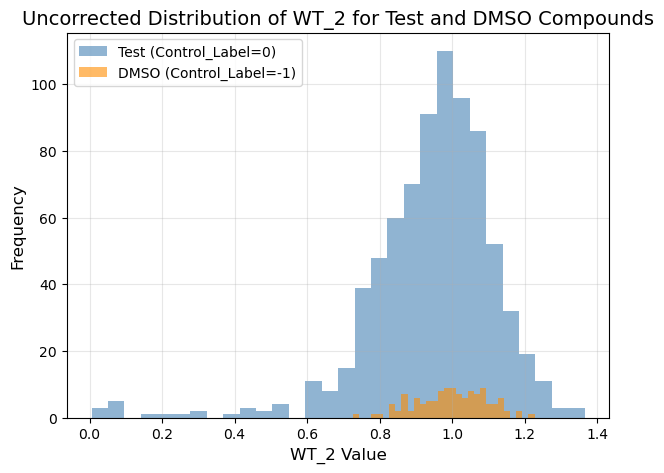

In [7]:
# Filter subsets
df_test = WT_2_well_df[WT_2_well_df["Control_Label"] == 0]
df_dmso = WT_2_well_df[WT_2_well_df["Control_Label"] == -1]

plt.figure(figsize=(7,5))

# Plot histograms
plt.hist(df_test["OD"], bins=30, alpha=0.6, label="Test (Control_Label=0)", color="steelblue")
plt.hist(df_dmso["OD"], bins=30, alpha=0.6, label="DMSO (Control_Label=-1)", color="darkorange")

# Labels and legend
plt.xlabel("WT_2 Value", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Uncorrected Distribution of WT_2 for Test and DMSO Compounds", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Now I need to use the DMSO information to correct the test WT_2 distibutions

In [8]:
WT_2_well_df=label_inactives_actives(WT_2_well_df, mad_multiplier=3) #positive controls are labeles as active here

/tmp/ipykernel_890689/552325782.py:215: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


In [9]:
WT_2_well_df_corrected, global_medians, well_medians = correct_well_batch_effect_time(WT_2_well_df)

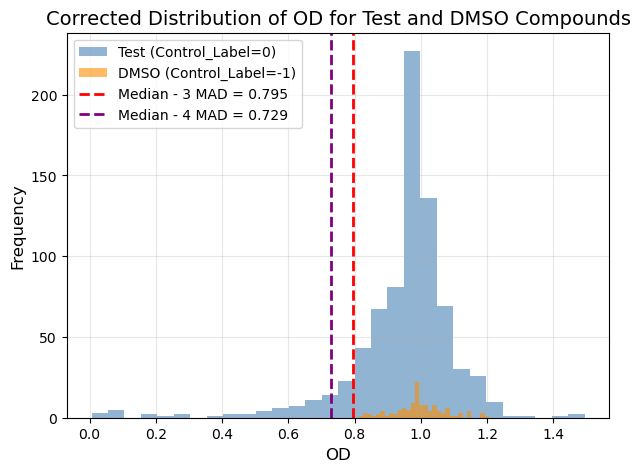

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Filter subsets
df_test = WT_2_well_df_corrected[WT_2_well_df_corrected["Control_Label"] == 0]
df_dmso = WT_2_well_df_corrected[WT_2_well_df_corrected["Control_Label"] == -1]

# Compute DMSO median and MAD (scaled)
dmso_median = np.median(df_dmso["OD"])
dmso_mad = 1.4826 * np.median(np.abs(df_dmso["OD"] - dmso_median))

# Threshold values
thresh_3 = dmso_median - 3 * dmso_mad
thresh_4 = dmso_median - 4 * dmso_mad

# Plot histograms
plt.figure(figsize=(7,5))
plt.hist(df_test["OD"], bins=30, alpha=0.6, label="Test (Control_Label=0)", color="steelblue")
plt.hist(df_dmso["OD"], bins=30, alpha=0.6, label="DMSO (Control_Label=-1)", color="darkorange")

# Add vertical lines with numeric values in legend
plt.axvline(thresh_3, color='red', linestyle='--', linewidth=2, 
            label=f"Median - 3 MAD = {thresh_3:.3f}")
plt.axvline(thresh_4, color='purple', linestyle='--', linewidth=2, 
            label=f"Median - 4 MAD = {thresh_4:.3f}")

# Labels and legend
plt.xlabel("OD", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Corrected Distribution of OD for Test and DMSO Compounds", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [11]:
WT_2_well_df_corrected_mad_3 = label_inactives_actives(WT_2_well_df_corrected, mad_multiplier=3)
WT_2_well_df_corrected_mad_4 = label_inactives_actives(WT_2_well_df_corrected, mad_multiplier=4)

/tmp/ipykernel_890689/552325782.py:215: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)
/tmp/ipykernel_890689/552325782.py:215: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


In [12]:
WT_2_well_df_corrected_mad_4

,Plate_ID,Well,OD,Compound,Strain,Replicate,Smiles,Concentration,Timepoint,Control_Label,is_Active
0,Plate13,C3,1.192008,UM0106093,WT,2,CCc(cccc1)c1N(CC(N1CCC(C)CC1)=O)S(c1ccc(C)cc1)...,50.0,12.0,0,0
1,Plate14,C3,0.986867,UM0007456,WT,2,C(c1ccccc1)Sc1nnc(-c2ccccc2)[o]1,50.0,12.0,0,0
2,Plate15,C3,0.782989,UM0046237,WT,2,CC(C)(C)c(cc1)ccc1Oc(cc1)ncc1NC(c1ccc[o]1)=O,50.0,12.0,0,1
3,Plate16,C3,0.363093,UM0055913,WT,2,CSc1nnc(Sc2ncc([N+]([O-])=O)[s]2)[s]1,50.0,12.0,0,1
4,Plate13,C4,1.047159,UM0116116,WT,2,Cc(ccc(S(N(C)C)(=O)=O)c1)c1NC(Nc(cc1)ccc1OC(F)...,50.0,12.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
952,Plate16,N21,0.881542,UM0151380,WT,2,[O-][N+](c(cc1)cnc1N/N=C/c1cc(Cl)cc(Cl)c1O)=O,50.0,12.0,0,0
953,Plate13,N22,0.931564,UM0100719,WT,2,O=C(c(cc(c(F)c1)F)c1Cl)[n]1nccc1,50.0,12.0,0,0
954,Plate14,N22,1.042169,UM0022303,WT,2,CCC(C)c(cc1)cc(NC(NC(c2cccc(Br)c2)=O)=S)c1O,50.0,12.0,0,0
955,Plate15,N22,0.006186,UM0041978,WT,2,Nc1nnc(-c2ccc([N+]([O-])=O)[o]2)[s]1,50.0,12.0,0,1


In [14]:
plate='Plate16'

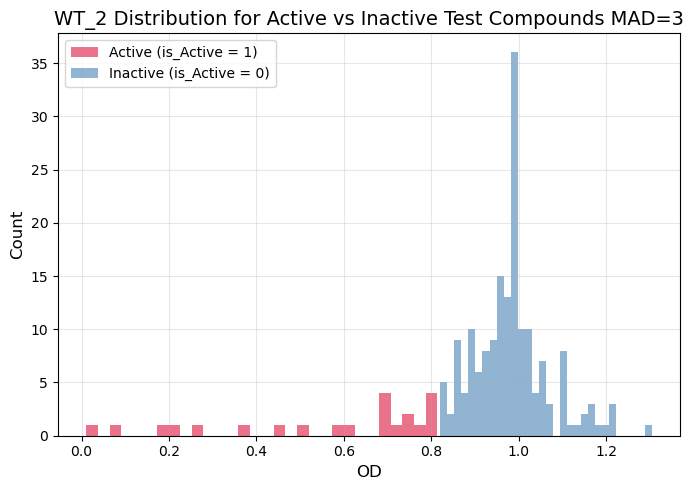

In [14]:
WT_2_well_df_corrected_mad_3[(WT_2_well_df_corrected_mad_3['OD'] < 0.795) & (WT_2_well_df_corrected_mad_3['Control_Label'] == 0)].shape,WT_2_well_df_corrected_mad_3[(WT_2_well_df_corrected_mad_3['OD'] < 0.795) & (WT_2_well_df_corrected_mad_3['Control_Label'] == 0)]['is_Active'].sum()

import matplotlib.pyplot as plt

# Filter subsets
df_test_active = WT_2_well_df_corrected_mad_3[
    (WT_2_well_df_corrected_mad_3["Control_Label"] == 0) &
    (WT_2_well_df_corrected_mad_3["is_Active"] == 1)
    & (WT_2_well_df_corrected_mad_4["Plate_ID"] == plate)
]

df_test_inactive = WT_2_well_df_corrected_mad_3[
    (WT_2_well_df_corrected_mad_3["Control_Label"] == 0) &
    (WT_2_well_df_corrected_mad_3["is_Active"] == 0)
    & (WT_2_well_df_corrected_mad_4["Plate_ID"] == plate)
]

# Plot histograms
plt.figure(figsize=(7,5))
plt.hist(df_test_active["OD"], bins=30, alpha=0.6, label="Active (is_Active = 1)", color="crimson")
plt.hist(df_test_inactive["OD"], bins=30, alpha=0.6, label="Inactive (is_Active = 0)", color="steelblue")

# Labels and legend
plt.xlabel("OD", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("WT_2 Distribution for Active vs Inactive Test Compounds MAD=3", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [16]:
WT_2_well_df_corrected_mad_4['Plate_ID'].unique()

array(['Plate13', 'Plate14', 'Plate15', 'Plate16'], dtype=object)

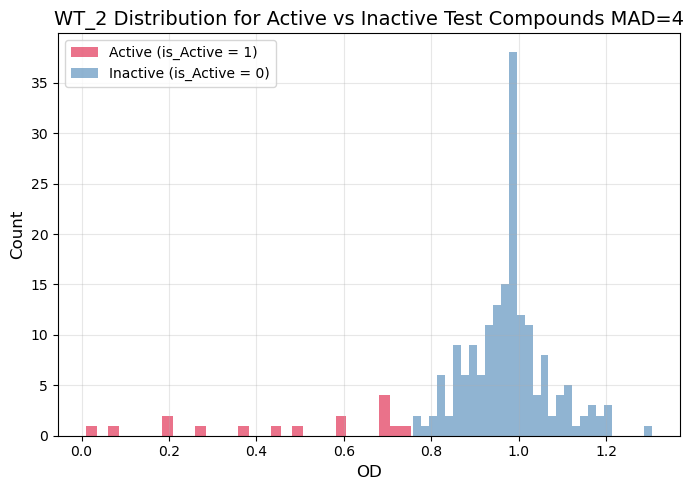

In [15]:
#WT_2_well_df_corrected_mad_4[(WT_2_well_df_corrected_mad_4['OD'] < 0.729) & (WT_2_well_df_corrected_mad_4['Control_Label'] == 0)].shape,WT_2_well_df_corrected_mad_4[(WT_2_well_df_corrected_mad_4['OD'] < 0.729) & (WT_2_well_df_corrected_mad_4['Control_Label'] == 0)]['is_Active'].sum()


import matplotlib.pyplot as plt

# Filter subsets
df_test_active = WT_2_well_df_corrected_mad_4[
    (WT_2_well_df_corrected_mad_4["Control_Label"] == 0) &
    (WT_2_well_df_corrected_mad_4["is_Active"] == 1) 
    & (WT_2_well_df_corrected_mad_4["Plate_ID"] == plate)
]

df_test_inactive = WT_2_well_df_corrected_mad_4[
    (WT_2_well_df_corrected_mad_4["Control_Label"] == 0) &
    (WT_2_well_df_corrected_mad_4["is_Active"] == 0)
    & (WT_2_well_df_corrected_mad_4["Plate_ID"] ==plate)
]

# Plot histograms
plt.figure(figsize=(7,5))
plt.hist(df_test_active["OD"], bins=30, alpha=0.6, label="Active (is_Active = 1)", color="crimson")
plt.hist(df_test_inactive["OD"], bins=30, alpha=0.6, label="Inactive (is_Active = 0)", color="steelblue")

# Labels and legend
plt.xlabel("OD", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("WT_2 Distribution for Active vs Inactive Test Compounds MAD=4", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Looking at the per plate distributions, I think the actives from mad=4 is best

# Normalize distribution of WT_1 in OD-777-GrowthCurves.csv

In [16]:
GrowthCurve_WT_1_df = pd.read_csv('/home/ethan2/GrowthCurve/data/test/OD-777-GrowthCurves.csv')

GrowthCurve_WT_1_df.rename(columns={'Plate':'Plate_ID'}, inplace=True)

GrowthCurve_WT_1_df['Concentration'] = 50.0

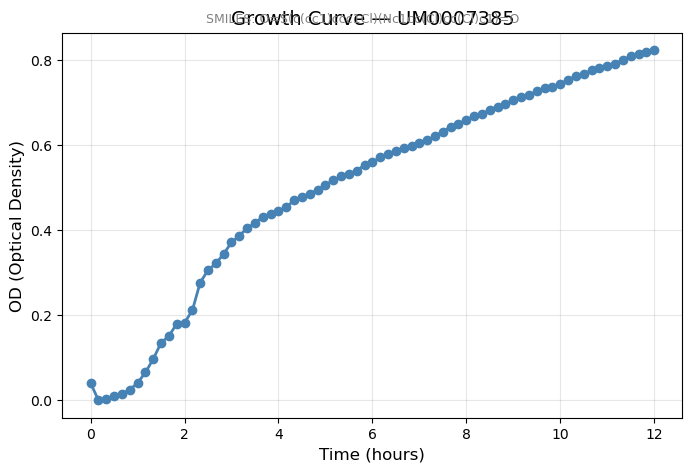

Plotted compound: UM0007385


In [17]:
compound_name = plot_random_growth_curve(GrowthCurve_WT_1_df)
print(f"Plotted compound: {compound_name}")

In [18]:
# Identify all the timepoint columns
time_cols = [col for col in GrowthCurve_WT_1_df.columns if col.startswith("t_")]

# Melt the dataframe
GrowthCurve_WT_1_df = GrowthCurve_WT_1_df.melt(
    id_vars=["Compound", "Plate_ID", "Well", "Smiles", 'Concentration'],  # columns to keep fixed
    value_vars=time_cols,                             # columns to melt
    var_name="Timepoint",                             # new column name for timepoints
    value_name="OD"                                   # new column name for OD values
)

# Clean the Timepoint column to remove the 't_' prefix and convert to float
GrowthCurve_WT_1_df["Timepoint"] = (
    GrowthCurve_WT_1_df["Timepoint"].str.replace("t_", "", regex=False).astype(float)
)

In [19]:
non_um_compounds = GrowthCurve_WT_1_df.loc[
    ~GrowthCurve_WT_1_df["Compound"].str.startswith("UM", na=False), 
    "Compound"
].unique()

# Display them
print(non_um_compounds)

GrowthCurve_WT_1_df["Control_Label"] = np.select(
    [
        GrowthCurve_WT_1_df["Compound"] == "DMSO",  # condition 1
        GrowthCurve_WT_1_df["Compound"].isin(["Tetracycline", "Chloramphenicol", "Ciprofloxacin"])  # condition 2
    ],
    [
        -1,  # value if DMSO
        1    # value if antibiotic control
    ],
    default=0  # all others
)

['Ciprofloxacin' 'DMSO' 'Chloramphenicol' 'Tetracycline']


In [20]:
GrowthCurve_WT_1_df['Control_Label'].value_counts()

Control_Label
 0    56721
-1     8760
 1     4380
Name: count, dtype: int64

In [ ]:
bins={
    -1: 15,  # DMSO
     0: 35,  # Test compounds
     1: 15   # Positive controls
}
plot_hist_od_distributions_long(
    title='Uncorrected WT_1',
    correct_uncorrect = 'Uncorrected',
    dataset="Test",
    df_long=GrowthCurve_WT_1_df,
    bins = bins,                       
    concentration = 50,
    max_density=6,
    max_x=1.5,
    plot_pos_ctrls=False, 
    save_path = False
)

Now correct the distribution of test compounds

In [21]:
test=label_inactives_actives(GrowthCurve_WT_1_df, mad_multiplier=3)

GrowthCurve_WT_1_df_corrected, global_medians, well_medians = correct_well_batch_effect_time(test)

/tmp/ipykernel_890689/552325782.py:215: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


In [ ]:
plot_hist_od_distributions_long(
    title='Corrected WT_1',
    correct_uncorrect = 'Uncorrected',
    dataset="Test",
    df_long=GrowthCurve_WT_1_df_corrected,
    bins = bins,                       
    concentration = 50,
    max_density=6,
    max_x=1.5,
    plot_pos_ctrls=False, 
    save_path = False
)

In [22]:
#GrowthCurve_WT_1_df_corrected_mad_3 = label_inactives_actives(GrowthCurve_WT_1_df_corrected, mad_multiplier=3)
GrowthCurve_WT_1_df_corrected_mad_4 = label_inactives_actives(GrowthCurve_WT_1_df_corrected, mad_multiplier=4)

/tmp/ipykernel_890689/552325782.py:215: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_thresh)


Need to resolve WT_1 and WT_2 replicates at time 12 and conc 50

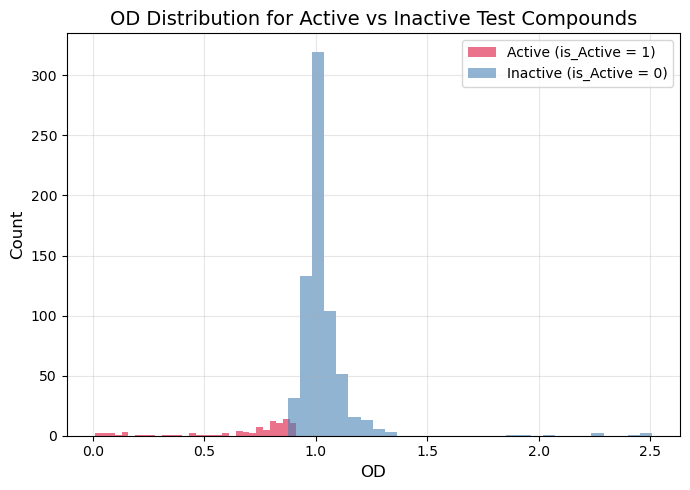

In [ ]:
'''
GrowthCurve_WT_1_df_corrected_mad_3_12_50 = GrowthCurve_WT_1_df_corrected_mad_3[(GrowthCurve_WT_1_df_corrected_mad_3['Concentration'] == 50.0) & (GrowthCurve_WT_1_df_corrected_mad_3['Timepoint'] == 12.0)]

# Filter subsets
df_test_active = GrowthCurve_WT_1_df_corrected_mad_3_12_50[
    (GrowthCurve_WT_1_df_corrected_mad_3_12_50["Control_Label"] == 0) &
    (GrowthCurve_WT_1_df_corrected_mad_3_12_50["is_Active"] == 1) 
    #& (GrowthCurve_WT_1_df_corrected_mad_4_12_50["Plate_ID"] == plate)
]

df_test_inactive = GrowthCurve_WT_1_df_corrected_mad_3_12_50[
    (GrowthCurve_WT_1_df_corrected_mad_3_12_50["Control_Label"] == 0) &
    (GrowthCurve_WT_1_df_corrected_mad_3_12_50["is_Active"] == 0)
    #& (WT_2_well_df_corrected_mad_4["Plate_ID"] ==plate)
]

# Plot histograms
plt.figure(figsize=(7,5))
plt.hist(df_test_active["OD"], bins=30, alpha=0.6, label="Active (is_Active = 1)", color="crimson")
plt.hist(df_test_inactive["OD"], bins=30, alpha=0.6, label="Inactive (is_Active = 0)", color="steelblue")

# Labels and legend
plt.xlabel("OD", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("OD Distribution for Active vs Inactive Test Compounds", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
'''

In [24]:
GrowthCurve_WT_1_df_corrected_mad_4_12_50 = GrowthCurve_WT_1_df_corrected_mad_4[ GrowthCurve_WT_1_df_corrected_mad_4['Timepoint'] == 12.0]

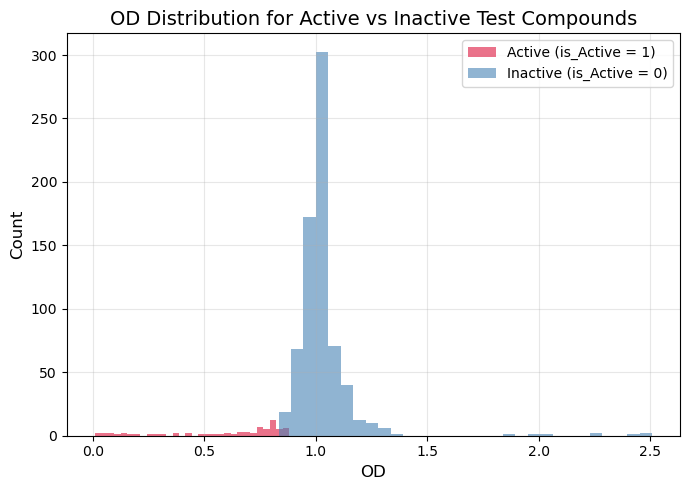

In [25]:

# Filter subsets
df_test_active = GrowthCurve_WT_1_df_corrected_mad_4_12_50[
    (GrowthCurve_WT_1_df_corrected_mad_4_12_50["Control_Label"] == 0) &
    (GrowthCurve_WT_1_df_corrected_mad_4_12_50["is_Active"] == 1) 
    #& (GrowthCurve_WT_1_df_corrected_mad_4_12_50["Plate_ID"] == plate)
]

df_test_inactive = GrowthCurve_WT_1_df_corrected_mad_4_12_50[
    (GrowthCurve_WT_1_df_corrected_mad_4_12_50["Control_Label"] == 0) &
    (GrowthCurve_WT_1_df_corrected_mad_4_12_50["is_Active"] == 0)
    #& (WT_2_well_df_corrected_mad_4["Plate_ID"] ==plate)
]

# Plot histograms
plt.figure(figsize=(7,5))
plt.hist(df_test_active["OD"], bins=30, alpha=0.6, label="Active (is_Active = 1)", color="crimson")
plt.hist(df_test_inactive["OD"], bins=30, alpha=0.6, label="Inactive (is_Active = 0)", color="steelblue")

# Labels and legend
plt.xlabel("OD", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("OD Distribution for Active vs Inactive Test Compounds", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
GrowthCurve_WT_1_df_corrected_mad_4_12_50[(GrowthCurve_WT_1_df_corrected_mad_4_12_50['Control_Label'] == 0) & (GrowthCurve_WT_1_df_corrected_mad_4_12_50['is_Active'] == 1)]

,Compound,Plate_ID,Well,Smiles,Concentration,Timepoint,OD,Control_Label,is_Active
68934,UM0007743,Plate10,D13,O=C(Nc1cc(F)ccc1)Nc(cc1)cc(Cl)c1Cl,50.0,12.0,0.595142,0,1
68944,UM0037703,Plate10,E3,CCN(C=C(C(O)=O)C(c1c2)=O)c1cc(N(CC1)CCN1C(Nc(c...,50.0,12.0,0.104757,0,1
68973,UM0008664,Plate10,F12,CC(c1ccccc1)NC(Nc(cc1)cc(Cl)c1Cl)=O,50.0,12.0,0.710135,0,1
68984,UM0008648,Plate10,G3,O=C(Nc1cc(Cl)ccc1)Nc(cc1)cc(Cl)c1F,50.0,12.0,0.823548,0,1
68985,UM0015696,Plate10,G4,CCOc(cc1)cc(O)c1-c1n[nH]cc1-c1ccccc1,50.0,12.0,0.846825,0,1
...,...,...,...,...,...,...,...,...,...
69800,UM0113497,Plate9,K22,O=C(Nc1nnc(C(F)(F)F)[s]1)Nc(cc1)ccc1Cl,50.0,12.0,0.369587,0,1
69814,UM0107666,Plate9,L16,CC(C)S(c1c[s]c(NC(Nc2cc(Cl)cc(Cl)c2)=O)c1)(=O)=O,50.0,12.0,0.648319,0,1
69821,UM0107710,Plate9,M3,CC(C)S(c1c[s]c(NC(Nc2ccc(C(F)(F)F)cc2)=O)c1)(=...,50.0,12.0,0.664424,0,1
69834,UM0034624,Plate9,M16,COC(CC(C(NC1C2CCCC1)=O)N2C(Nc(cc1)cc(Cl)c1Cl)=...,50.0,12.0,0.797527,0,1


What compounds are active in WT_2, not in WT_1?

In [35]:
active_wt1 = set(
    GrowthCurve_WT_1_df_corrected_mad_4_12_50.loc[
        (GrowthCurve_WT_1_df_corrected_mad_4_12_50["Control_Label"] == 0) &
        (GrowthCurve_WT_1_df_corrected_mad_4_12_50["is_Active"] == 1),
        "Compound"
    ]
)

active_wt2 = set(
    WT_2_well_df_corrected_mad_4.loc[
        (WT_2_well_df_corrected_mad_4["Control_Label"] == 0) &
        (WT_2_well_df_corrected_mad_4["is_Active"] == 1),
        "Compound"
    ]
)


print(f"actives in WT_1: {len(active_wt1)}")
print(f"actives in WT_2: {len(active_wt2)}")
# Compare
active_in_wt1_not_wt2 = active_wt1 - active_wt2
active_in_wt2_not_wt1 = active_wt2 - active_wt1
overlap = active_wt1 & active_wt2

# Print results
print(f"Active in WT_1 but not in WT_2 ({len(active_in_wt1_not_wt2)}):")
print(sorted(active_in_wt1_not_wt2))

print(f"\nActive in WT_2 but not in WT_1 ({len(active_in_wt2_not_wt1)}):")
print(sorted(active_in_wt2_not_wt1))

print(f"\nActive in both WT_1 and WT_2 ({len(overlap)}):")
print(sorted(overlap))

actives in WT_1: 68
actives in WT_2: 53
Active in WT_1 but not in WT_2 (35):
['UM0008648', 'UM0008664', 'UM0011273', 'UM0015696', 'UM0018759', 'UM0029428', 'UM0031014', 'UM0033243', 'UM0038076', 'UM0041481', 'UM0042754', 'UM0043358', 'UM0043407', 'UM0051417', 'UM0051945', 'UM0052408', 'UM0055117', 'UM0058842', 'UM0060699', 'UM0062428', 'UM0062475', 'UM0063431', 'UM0065446', 'UM0070625', 'UM0071051', 'UM0074148', 'UM0074187', 'UM0096275', 'UM0107710', 'UM0109283', 'UM0114541', 'UM0117826', 'UM0117999', 'UM0150774', 'UM0151620']

Active in WT_2 but not in WT_1 (20):
['UM0006738', 'UM0034443', 'UM0036198', 'UM0040737', 'UM0041047', 'UM0041755', 'UM0043836', 'UM0043876', 'UM0043938', 'UM0046237', 'UM0047910', 'UM0050584', 'UM0050951', 'UM0051132', 'UM0051579', 'UM0052666', 'UM0055724', 'UM0150486', 'UM0150808', 'UM0150938']

Active in both WT_1 and WT_2 (33):
['UM0007743', 'UM0007769', 'UM0012924', 'UM0024419', 'UM0025744', 'UM0030067', 'UM0034624', 'UM0035377', 'UM0037703', 'UM0041978', '

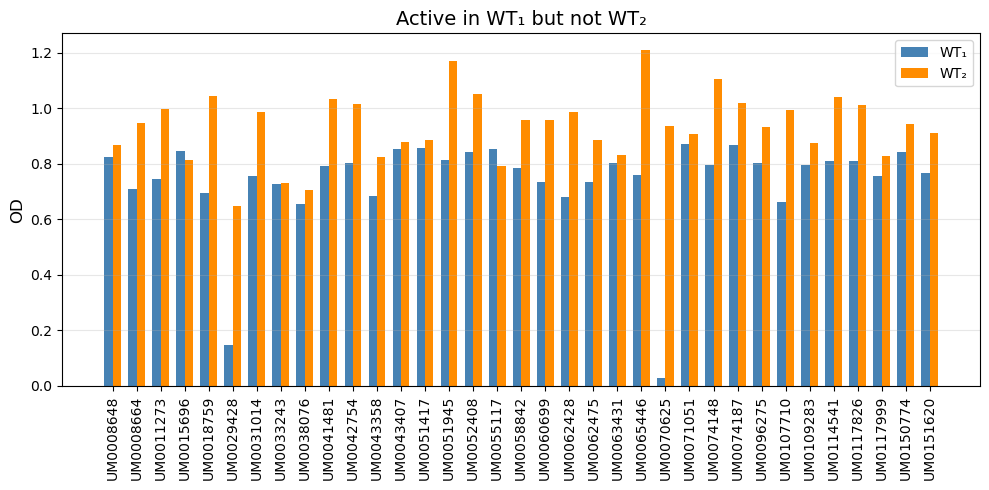

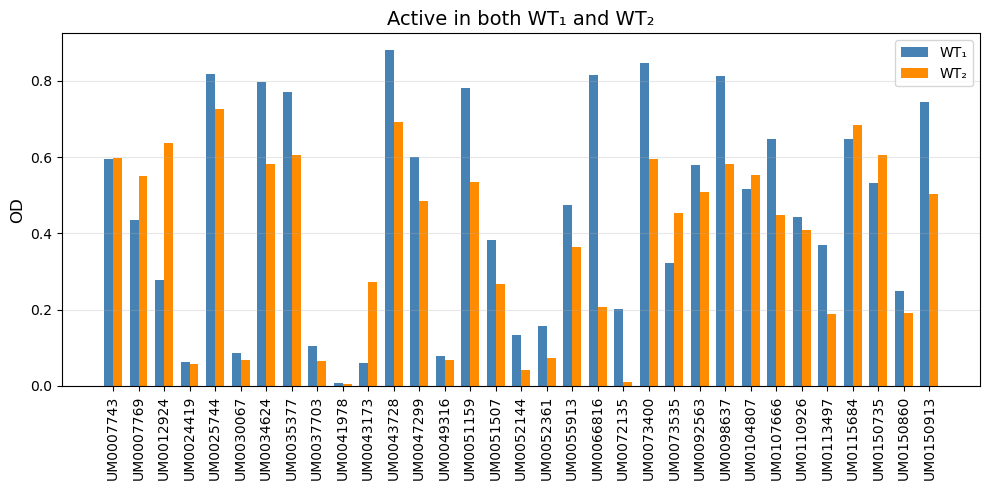

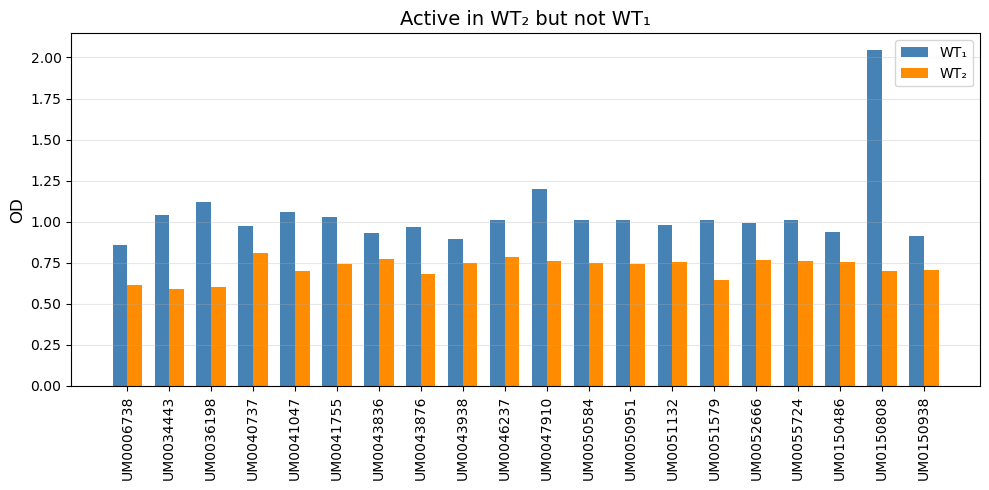

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Filter down to test wells only ---
df_wt1 = GrowthCurve_WT_1_df_corrected_mad_4_12_50[
    (GrowthCurve_WT_1_df_corrected_mad_4_12_50["Control_Label"] == 0)
][["Compound", "OD"]].rename(columns={"OD": "WT_1_OD"})

df_wt2 = WT_2_well_df_corrected_mad_4[
    (WT_2_well_df_corrected_mad_4["Control_Label"] == 0)
][["Compound", "OD"]].rename(columns={"OD": "WT_2_OD"})

# Merge them so we always have both ODs per compound
merged = pd.merge(df_wt1, df_wt2, on="Compound", how="outer")

# --- Subsets of interest ---
df_wt1_only = merged[merged["Compound"].isin(active_in_wt1_not_wt2)]
df_wt2_only = merged[merged["Compound"].isin(active_in_wt2_not_wt1)]
df_both     = merged[merged["Compound"].isin(overlap)]

# --- Helper function for plotting ---
def plot_od_comparison(df, title):
    plt.figure(figsize=(10,5))
    x = range(len(df))
    width = 0.35

    plt.bar([i - width/2 for i in x], df["WT_1_OD"], width=width, label="WT₁", color="steelblue")
    plt.bar([i + width/2 for i in x], df["WT_2_OD"], width=width, label="WT₂", color="darkorange")

    plt.xticks(x, df["Compound"], rotation=90)
    plt.ylabel("OD", fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

# --- Plot 1: Active in WT₁ but not WT₂ ---
plot_od_comparison(df_wt1_only, "Active in WT₁ but not WT₂")

# --- Plot 2: Active in both WT₁ and WT₂ ---
plot_od_comparison(df_both, "Active in both WT₁ and WT₂")

# --- Plot 3: Active in WT₂ but not WT₁ ---
plot_od_comparison(df_wt2_only, "Active in WT₂ but not WT₁")


In [107]:
cmp='UM0070625'

WT_2_well_df_corrected_mad_4[WT_2_well_df_corrected_mad_4['Compound'] == cmp]

,Plate_ID,Well,OD,Compound,Strain,Replicate,Smiles,Concentration,Timepoint,Control_Label,is_Active
829,Plate16,M10,0.93789,UM0070625,WT,2,CN(C)C=C(C(N(C1CCCCC1)C(N1C2CCCCC2)=O)=O)C1=O,50.0,12.0,0,0


In [108]:
GrowthCurve_WT_1_df_corrected_mad_4[GrowthCurve_WT_1_df_corrected_mad_4['Compound'] == cmp]

,Compound,Plate_ID,Well,Smiles,Concentration,Timepoint,OD,Control_Label,is_Active
478,UM0070625,Plate12,C3,CN(C)C=C(C(N(C1CCCCC1)C(N1C2CCCCC2)=O)=O)C1=O,50.0,0.000,0.026732,0,0
1435,UM0070625,Plate12,C3,CN(C)C=C(C(N(C1CCCCC1)C(N1C2CCCCC2)=O)=O)C1=O,50.0,0.167,0.000000,0,0
2392,UM0070625,Plate12,C3,CN(C)C=C(C(N(C1CCCCC1)C(N1C2CCCCC2)=O)=O)C1=O,50.0,0.333,0.002228,0,1
3349,UM0070625,Plate12,C3,CN(C)C=C(C(N(C1CCCCC1)C(N1C2CCCCC2)=O)=O)C1=O,50.0,0.500,0.002660,0,0
4306,UM0070625,Plate12,C3,CN(C)C=C(C(N(C1CCCCC1)C(N1C2CCCCC2)=O)=O)C1=O,50.0,0.667,0.003347,0,1
...,...,...,...,...,...,...,...,...,...
65554,UM0070625,Plate12,C3,CN(C)C=C(C(N(C1CCCCC1)C(N1C2CCCCC2)=O)=O)C1=O,50.0,11.333,0.026073,0,1
66511,UM0070625,Plate12,C3,CN(C)C=C(C(N(C1CCCCC1)C(N1C2CCCCC2)=O)=O)C1=O,50.0,11.500,0.026040,0,1
67468,UM0070625,Plate12,C3,CN(C)C=C(C(N(C1CCCCC1)C(N1C2CCCCC2)=O)=O)C1=O,50.0,11.667,0.028022,0,1
68425,UM0070625,Plate12,C3,CN(C)C=C(C(N(C1CCCCC1)C(N1C2CCCCC2)=O)=O)C1=O,50.0,11.833,0.027980,0,1


In [37]:
false_positives = [
    "UM0000191", "UM0001775", "UM0005027", "UM0006747", "UM0006796", "UM0008118",
    "UM0011068", "UM0011336", "UM0011631", "UM0012843", "UM0016596", "UM0017885",
    "UM0023966", "UM0029428", "UM0037496", "UM0042628", "UM0042826", "UM0049563",
    "UM0050215", "UM0050743", "UM0050950", "UM0051855", "UM0052363", "UM0052435",
    "UM0067767", "UM0067943", "UM0067944", "UM0067946", "UM0069817", "UM0074839",
    "UM0104363", "UM0109930", "UM0110870", "UM0110934", "UM0114400", "UM0117817",
    "UM0117826", "UM0150660", "UM0151547"
]


false_negatives = [
    "UM0006738", "UM0007743", "UM0007769", "UM0024419", "UM0025744", "UM0034443",
    "UM0034624", "UM0035377", "UM0036198", "UM0041047", "UM0041755", "UM0041978",
    "UM0043173", "UM0043728", "UM0043836", "UM0043938", "UM0046237", "UM0049316",
    "UM0050584", "UM0050951", "UM0051159", "UM0051507", "UM0051579", "UM0052666",
    "UM0055724", "UM0055913", "UM0066816", "UM0072135", "UM0073400", "UM0073535",
    "UM0104807", "UM0107666", "UM0113497", "UM0115684", "UM0150486", "UM0150735",
    "UM0150808", "UM0150860", "UM0150913", "UM0150938"
]

len(false_positives),len(false_negatives)

(39, 40)

In [38]:
filtered_fp = GrowthCurve_WT_1_df_corrected_mad_4_12_50[
    (GrowthCurve_WT_1_df_corrected_mad_4_12_50["Control_Label"] == 0) &
    (GrowthCurve_WT_1_df_corrected_mad_4_12_50["Compound"].isin(false_positives))
]
filtered_fp['is_Active'].value_counts()

is_Active
0    37
1     2
Name: count, dtype: int64

In [39]:
filtered_fn = GrowthCurve_WT_1_df_corrected_mad_4_12_50[
    (GrowthCurve_WT_1_df_corrected_mad_4_12_50["Control_Label"] == 0) &
    (GrowthCurve_WT_1_df_corrected_mad_4_12_50["Compound"].isin(false_negatives))
]
filtered_fn['is_Active'].value_counts()

is_Active
1    24
0    16
Name: count, dtype: int64

# Make test dict at time 12 and conc 50 where actives are active when both WT_1 and WT_2 agree

In [40]:
WT_1 = GrowthCurve_WT_1_df_corrected_mad_4[(GrowthCurve_WT_1_df_corrected_mad_4['Timepoint'] == 12.0) & (GrowthCurve_WT_1_df_corrected_mad_4['Control_Label'] == 0)]
WT_2_well_df_corrected_mad_4_no_ctrls= WT_2_well_df_corrected_mad_4[WT_2_well_df_corrected_mad_4['Control_Label'] == 0]

#Do not need controls here since I will not be remaking activity labels


In [42]:
import pandas as pd

# --- Step 1: select and rename the key columns from each replicate ---
wt1 = WT_1[[
    "Compound", "Plate_ID", "Well", "Smiles", "Concentration", "Timepoint",
    "OD", "Control_Label", "is_Active"
]].rename(columns={"OD": "WT_1_OD", "is_Active": "WT_1_is_Active"})

wt2 = WT_2_well_df_corrected_mad_4_no_ctrls[[
    "Compound", "Plate_ID", "Well", "Smiles", "Concentration", "Timepoint",
    "OD", "Control_Label", "is_Active"
]].rename(columns={"OD": "WT_2_OD", "is_Active": "WT_2_is_Active"})

# --- Step 2: merge replicates on 'Compound' ---
merged = pd.merge(
    wt1, wt2,
    on=["Compound", "Smiles", "Concentration", "Timepoint", "Control_Label"],
    how="outer",
    suffixes=("_WT1", "_WT2")
)

# --- Step 3: compute the averaged OD ---
merged["OD"] = merged[["WT_1_OD", "WT_2_OD"]].mean(axis=1, skipna=True)

# --- Step 4: compute the joint is_Active (1 only if both are active) ---
merged["is_Active"] = (
    (merged["WT_1_is_Active"] == 1) & (merged["WT_2_is_Active"] == 1)
).astype(int)


# --- Step 5: build final combined DataFrame ---
combined_df = merged[[
    "Compound", "Smiles", "Concentration", "Timepoint",
    "OD", "Control_Label", "is_Active"
]].copy()

# --- Step 7: inspect result ---
print(combined_df.head())
print("Final columns:", combined_df.columns.tolist())


    Compound                                             Smiles  \
0  UM0000191              Oc(c(Cl)cc(-c(cc1Cl)cc(Cl)c1O)c1)c1Cl   
1  UM0000649                  O=C(c1ccccc1)Nc(cc1)ccc1Oc1ccccc1   
2  UM0001162                  NC(CC1=O)=NN1c(c(Cl)cc(Cl)c1)c1Cl   
3  UM0001321                Oc(cccc1)c1S(Nc1cccc2c1nccc2)(=O)=O   
4  UM0001370  CN(C)c(c(F)c(c(-c(c(F)c(c(N(C)C)c1F)F)c1F)c1F)...   

   Concentration  Timepoint        OD  Control_Label  is_Active  
0           50.0       12.0  0.994007              0          0  
1           50.0       12.0  1.041191              0          0  
2           50.0       12.0  0.979213              0          0  
3           50.0       12.0  0.960879              0          0  
4           50.0       12.0  1.064540              0          0  
Final columns: ['Compound', 'Smiles', 'Concentration', 'Timepoint', 'OD', 'Control_Label', 'is_Active']


Add the fingerpints then save

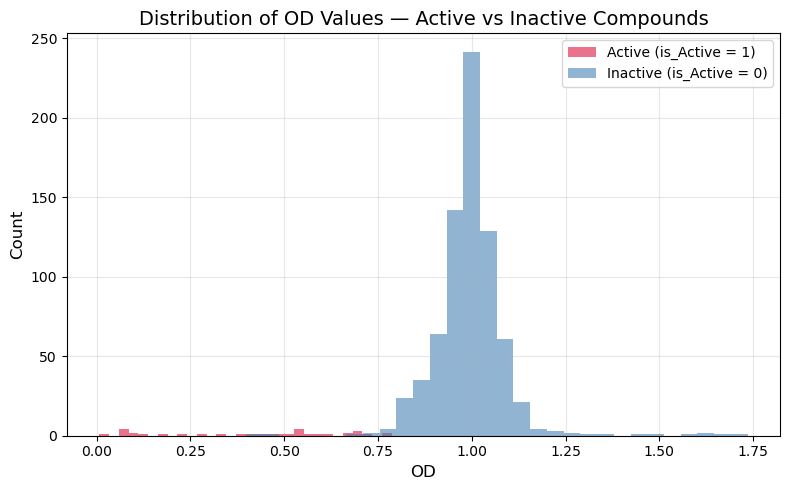

In [43]:
df_active = combined_df[combined_df["is_Active"] == 1]
df_inactive = combined_df[combined_df["is_Active"] == 0]

# Plot histograms
plt.figure(figsize=(8,5))
plt.hist(df_active["OD"], bins=30, alpha=0.6, color="crimson", label="Active (is_Active = 1)")
plt.hist(df_inactive["OD"], bins=30, alpha=0.6, color="steelblue", label="Inactive (is_Active = 0)")

# Labels and formatting
plt.xlabel("OD", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of OD Values — Active vs Inactive Compounds", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Bizare there are some inactives that definetly look active

In [44]:
combined_df["scaffold"] = combined_df["Smiles"].apply(compute_scaffold)
combined_df["maccs_fp"] = combined_df["Smiles"].apply(maccs_to_fp)
combined_df["ecfp_fp"] = combined_df["Smiles"].apply(ecfp_to_fp)
combined_df["rdkit_fp"] = combined_df["Smiles"].apply(rdkit_to_fp)

[13:10:58] Conflicting single bond directions around double bond at index 6.
[13:10:58]   BondStereo set to STEREONONE and single bond directions set to NONE.
[13:10:58] Conflicting single bond directions around double bond at index 3.
[13:10:58]   BondStereo set to STEREONONE and single bond directions set to NONE.
[13:10:58] Conflicting single bond directions around double bond at index 13.
[13:10:58]   BondStereo set to STEREONONE and single bond directions set to NONE.
[13:10:58] Conflicting single bond directions around double bond at index 7.
[13:10:58]   BondStereo set to STEREONONE and single bond directions set to NONE.
[13:10:58] Conflicting single bond directions around double bond at index 4.
[13:10:58]   BondStereo set to STEREONONE and single bond directions set to NONE.
[13:10:58] Conflicting single bond directions around double bond at index 12.
[13:10:58]   BondStereo set to STEREONONE and single bond directions set to NONE.
[13:10:58] Conflicting single bond direction

In [45]:
ds_test=ExplicitDataset(combined_df, num_fourier=3)
test_loader = DataLoader(ds_test, batch_size=len(ds_test),collate_fn=custom_collate)
test_whole_dict=next(iter(test_loader))

save_path = f"/home/ethan2/GrowthCurve/data/test/dict_test_normalized_actives_common_mad_4.pkl"

# Save
with open(save_path, "wb") as f:
    pickle.dump(test_whole_dict, f)

# Makes test set means the replicates and then remakes the actives based on new thrshold

In [27]:
WT_1=GrowthCurve_WT_1_df_corrected_mad_4[GrowthCurve_WT_1_df_corrected_mad_4['Timepoint'] == 12.0]
WT_1['Control_Label'].value_counts(),WT_2_well_df_corrected_mad_4['Control_Label'].value_counts()

(Control_Label
  0    777
 -1    120
  1     60
 Name: count, dtype: int64,
 Control_Label
  0    777
 -1    120
  1     60
 Name: count, dtype: int64)

In [28]:
import pandas as pd

# --- Step 1. Align columns and remove well/plate info ---
wt1 = WT_1.drop(columns=["Plate_ID", "Well"], errors="ignore")
wt2 = WT_2_well_df_corrected_mad_4.drop(columns=["Plate_ID", "Well", "Strain", "Replicate"], errors="ignore")

# --- Step 2. Split test compounds and controls ---
wt1_test = wt1[wt1["Control_Label"] == 0]
wt2_test = wt2[wt2["Control_Label"] == 0]

wt1_ctrl = wt1[wt1["Control_Label"].isin([-1, 1])]
wt2_ctrl = wt2[wt2["Control_Label"].isin([-1, 1])]

# --- Step 3. Merge and average test compounds by compound-level info ---
merged_test = pd.merge(
    wt1_test,
    wt2_test,
    on=["Compound", "Smiles", "Concentration", "Timepoint", "Control_Label"],
    how="inner",
    suffixes=("_WT1", "_WT2")
)

# Average ODs for test compounds
merged_test["OD"] = merged_test[["OD_WT1", "OD_WT2"]].mean(axis=1, skipna=True)

# Logical AND for is_Active (must be active in both)
merged_test["is_Active"] = (
    (merged_test["is_Active_WT1"] == 1) & (merged_test["is_Active_WT2"] == 1)
).astype(int)

# Keep only necessary columns
merged_test = merged_test[[
    "Compound", "Smiles", "Concentration", "Timepoint", "OD", "Control_Label", "is_Active"
]]

# --- Step 4. Concatenate controls (no averaging) ---
controls_combined = pd.concat([wt1_ctrl, wt2_ctrl], ignore_index=True)
controls_combined = controls_combined[[
    "Compound", "Smiles", "Concentration", "Timepoint", "OD", "Control_Label", "is_Active"
]]

# --- Step 5. Combine averaged tests and controls ---
combined_df = pd.concat([merged_test, controls_combined], ignore_index=True)

# --- Step 6. Sanity check ---
print(combined_df["Control_Label"].value_counts())
print(combined_df.head())


Control_Label
 0    777
-1    240
 1    120
Name: count, dtype: int64
    Compound                                             Smiles  \
0  UM0007118                 Brc1ccc(CSc2nnc(-c3ccccc3)[o]2)cc1   
1  UM0021732           COc1cccc(OCC(Nc(ccc(Cl)c2)c2C(O)=O)=O)c1   
2  UM0001321                Oc(cccc1)c1S(Nc1cccc2c1nccc2)(=O)=O   
3  UM0034122  O=C(C(CC1)CCC1N(C(C1C2C3CC1CC3)=O)C2=O)Nc1cccc...   
4  UM0038574            Cc1cc(OCCCN(C=Nc2c3cccc2)C3=O)cc(C)c1Cl   

   Concentration  Timepoint        OD  Control_Label  is_Active  
0           50.0       12.0  0.934442              0          0  
1           50.0       12.0  0.992180              0          0  
2           50.0       12.0  0.960879              0          0  
3           50.0       12.0  1.048486              0          0  
4           50.0       12.0  1.153752              0          0  


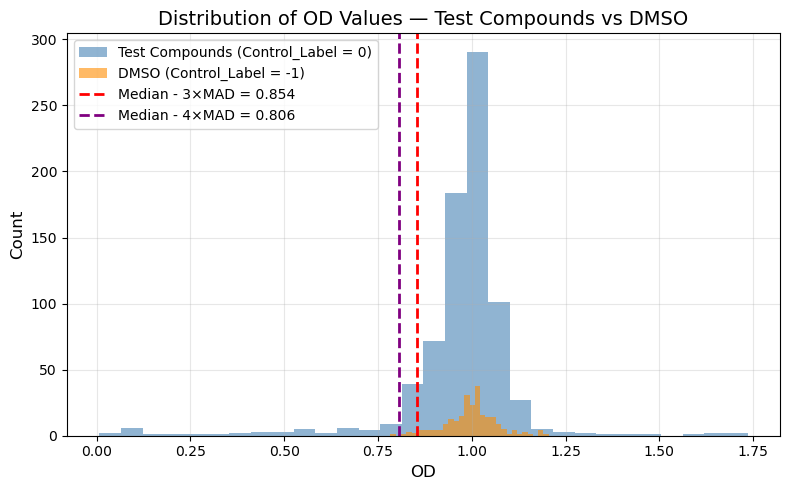

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Separate subsets
df_dmso = combined_df[combined_df["Control_Label"] == -1]
df_test = combined_df[combined_df["Control_Label"] == 0]

# --- Compute DMSO median and scaled MAD ---
dmso_median = np.median(df_dmso["OD"])
dmso_mad = 1.4826 * np.median(np.abs(df_dmso["OD"] - dmso_median))

# Thresholds
thresh_3 = dmso_median - 3 * dmso_mad
thresh_4 = dmso_median - 4 * dmso_mad

# --- Plot histograms ---
plt.figure(figsize=(8,5))
plt.hist(df_test["OD"], bins=30, alpha=0.6, color="steelblue",
         label="Test Compounds (Control_Label = 0)")
plt.hist(df_dmso["OD"], bins=30, alpha=0.6, color="darkorange",
         label="DMSO (Control_Label = -1)")

# --- Add vertical lines for thresholds ---
plt.axvline(thresh_3, color="red", linestyle="--", linewidth=2,
            label=f"Median - 3×MAD = {thresh_3:.3f}")
plt.axvline(thresh_4, color="purple", linestyle="--", linewidth=2,
            label=f"Median - 4×MAD = {thresh_4:.3f}")

# --- Formatting ---
plt.xlabel("OD", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of OD Values — Test Compounds vs DMSO", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [30]:
combined_no_ctrls = combined_df[combined_df["Control_Label"] == 0].copy()

# Update is_Active label based on OD threshold
combined_no_ctrls["is_Active"] = (combined_no_ctrls["OD"] < 0.806).astype(int)

print(combined_no_ctrls["is_Active"].value_counts())


is_Active
0    735
1     42
Name: count, dtype: int64


In [31]:
combined_no_ctrls["scaffold"] = combined_no_ctrls["Smiles"].apply(compute_scaffold)
combined_no_ctrls["maccs_fp"] = combined_no_ctrls["Smiles"].apply(maccs_to_fp)
combined_no_ctrls["ecfp_fp"] = combined_no_ctrls["Smiles"].apply(ecfp_to_fp)
combined_no_ctrls["rdkit_fp"] = combined_no_ctrls["Smiles"].apply(rdkit_to_fp)

[14:42:08] Conflicting single bond directions around double bond at index 3.
[14:42:08]   BondStereo set to STEREONONE and single bond directions set to NONE.
[14:42:08] Conflicting single bond directions around double bond at index 13.
[14:42:08]   BondStereo set to STEREONONE and single bond directions set to NONE.
[14:42:08] Conflicting single bond directions around double bond at index 6.
[14:42:08]   BondStereo set to STEREONONE and single bond directions set to NONE.
[14:42:08] Conflicting single bond directions around double bond at index 7.
[14:42:08]   BondStereo set to STEREONONE and single bond directions set to NONE.
[14:42:08] Conflicting single bond directions around double bond at index 19.
[14:42:08]   BondStereo set to STEREONONE and single bond directions set to NONE.
[14:42:08] Conflicting single bond directions around double bond at index 15.
[14:42:08]   BondStereo set to STEREONONE and single bond directions set to NONE.
[14:42:08] Conflicting single bond directio

In [34]:
def canonicalize_smiles(smi):
    """Return RDKit-canonicalized SMILES, or None if parsing fails."""
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        return Chem.MolToSmiles(mol, canonical=True)
    except:
        return None
    
combined_no_ctrls["Smiles_canonical"]   = combined_no_ctrls["Smiles"].apply(canonicalize_smiles)


[14:44:45] Conflicting single bond directions around double bond at index 3.
[14:44:45]   BondStereo set to STEREONONE and single bond directions set to NONE.
[14:44:45] Conflicting single bond directions around double bond at index 13.
[14:44:45]   BondStereo set to STEREONONE and single bond directions set to NONE.
[14:44:45] Conflicting single bond directions around double bond at index 6.
[14:44:45]   BondStereo set to STEREONONE and single bond directions set to NONE.
[14:44:45] Conflicting single bond directions around double bond at index 7.
[14:44:45]   BondStereo set to STEREONONE and single bond directions set to NONE.
[14:44:45] Conflicting single bond directions around double bond at index 19.
[14:44:45]   BondStereo set to STEREONONE and single bond directions set to NONE.
[14:44:45] Conflicting single bond directions around double bond at index 15.
[14:44:45]   BondStereo set to STEREONONE and single bond directions set to NONE.
[14:44:45] Conflicting single bond directio

In [36]:
combined_no_ctrls

,Compound,Smiles,Concentration,Timepoint,OD,Control_Label,is_Active,scaffold,maccs_fp,ecfp_fp,rdkit_fp,Smiles_canonical
0,UM0007118,Brc1ccc(CSc2nnc(-c3ccccc3)[o]2)cc1,50.0,12.0,0.934442,0,0,c1ccc(CSc2nnc(-c3ccccc3)o2)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ...",Brc1ccc(CSc2nnc(-c3ccccc3)o2)cc1
1,UM0021732,COc1cccc(OCC(Nc(ccc(Cl)c2)c2C(O)=O)=O)c1,50.0,12.0,0.992180,0,0,O=C(COc1ccccc1)Nc1ccccc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",COc1cccc(OCC(=O)Nc2ccc(Cl)cc2C(=O)O)c1
2,UM0001321,Oc(cccc1)c1S(Nc1cccc2c1nccc2)(=O)=O,50.0,12.0,0.960879,0,0,O=S(=O)(Nc1cccc2cccnc12)c1ccccc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, ...",O=S(=O)(Nc1cccc2cccnc12)c1ccccc1O
3,UM0034122,O=C(C(CC1)CCC1N(C(C1C2C3CC1CC3)=O)C2=O)Nc1cccc...,50.0,12.0,1.048486,0,0,O=C(Nc1ccccc1)C1CCC(N2C(=O)C3C4CCC(C4)C3C2=O)CC1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, ...",O=C(Nc1cccc(Cl)c1Cl)C1CCC(N2C(=O)C3C4CCC(C4)C3...
4,UM0038574,Cc1cc(OCCCN(C=Nc2c3cccc2)C3=O)cc(C)c1Cl,50.0,12.0,1.153752,0,0,O=c1c2ccccc2ncn1CCCOc1ccccc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",Cc1cc(OCCCn2cnc3ccccc3c2=O)cc(C)c1Cl
...,...,...,...,...,...,...,...,...,...,...,...,...
772,UM0106093,CCc(cccc1)c1N(CC(N1CCC(C)CC1)=O)S(c1ccc(C)cc1)...,50.0,12.0,1.084395,0,0,O=C(CN(c1ccccc1)S(=O)(=O)c1ccccc1)N1CCCCC1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, ...",CCc1ccccc1N(CC(=O)N1CCC(C)CC1)S(=O)(=O)c1ccc(C...
773,UM0110926,NC(NC(Nc(cc1)cc(Cl)c1Cl)=N)=N.Cl,50.0,12.0,0.425275,0,1,c1ccccc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, ...",Cl.N=C(N)NC(=N)Nc1ccc(Cl)c(Cl)c1
774,UM0110598,NC(C1=CN(C2CCCCC2)c(cccc2)c2C1=O)=O,50.0,12.0,1.031381,0,0,O=c1ccn(C2CCCCC2)c2ccccc12,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, ...",NC(=O)c1cn(C2CCCCC2)c2ccccc2c1=O
775,UM0116649,O=C(Nc(cc1)ccc1F)Nc(cc1)cnc1Oc1cc(C(F)(F)F)ccc1,50.0,12.0,1.096287,0,0,O=C(Nc1ccccc1)Nc1ccc(Oc2ccccc2)nc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, ...",O=C(Nc1ccc(F)cc1)Nc1ccc(Oc2cccc(C(F)(F)F)c2)nc1


In [ ]:
pd.to_pickle(combined_no_ctrls,"/home/ethan2/GrowthCurve/data/test/df_test_normalized_mean_OD_then_mad_4_t_12.pkl")

In [60]:
ds_test=ExplicitDataset(combined_no_ctrls, num_fourier=3)
test_loader = DataLoader(ds_test, batch_size=len(ds_test),collate_fn=custom_collate)
test_whole_dict=next(iter(test_loader))

save_path = f"/home/ethan2/GrowthCurve/data/test/dict_test_normalized_mean_OD_then_mad_4.pkl"

# Save
with open(save_path, "wb") as f:
    pickle.dump(test_whole_dict, f)